**Data Analysis and Visualization Lab - Midterm Exam - Fall 2023** <br>
Please note:
- Total marks are 25
- No internet or helping material is allowed
- You can use Google colab (if Jupyter is not installed on your system )
- Please submit your code on **Google Classroom**
- Add #Roll_Number as filename and download the .ipynb file, submit the file. No link sharing is allowed. No PDF/ZIP will be acceptable.
-Submit all question in single notebook file.
- The allowed time is **2 hours** including submission time


# Question 01: Naive Bayes

Just Run the cells where marks are not mentioned. Also training code is given, you just need to run the cell to train the model. You only have to test and predict the model.

In [4]:
import pdb
from nltk.corpus import stopwords, twitter_samples
import numpy as np
import pandas as pd
import nltk
import string
from nltk.tokenize import TweetTokenizer
from os import getcwd

If you are running this notebook in your local computer,
don't forget to download the twitter samples and stopwords from nltk.

```
nltk.download('stopwords')
nltk.download('twitter_samples')
```

In [18]:
# add folder, tmp2, from our local workspace containing pre-downloaded corpora files to nltk's data path
filePath = f"dataset.csv"
nltk.data.path.append(filePath)

In [19]:
# get the sets of positive and negative tweets
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

# split the data into two pieces, one for training and one for testing (validation set)
test_pos = all_positive_tweets[4000:]
train_pos = all_positive_tweets[:4000]
test_neg = all_negative_tweets[4000:]
train_neg = all_negative_tweets[:4000]

train_x = train_pos + train_neg
test_x = test_pos + test_neg

# avoid assumptions about the length of all_positive_tweets
train_y = np.append(np.ones(len(train_pos)), np.zeros(len(train_neg)))
test_y = np.append(np.ones(len(test_pos)), np.zeros(len(test_neg)))

In [20]:
custom_tweet = "RT @Twitter @chapagain Hello There! Have a great day. :) #good #morning http://chapagain.com.np"

# print cleaned tweet
print(process_tweet(custom_tweet))

NameError: ignored

[1 marks]

In [9]:
# UNQ_C1 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def count_tweets(result, tweets, ys):
    '''
    Input:
        result: a dictionary that will be used to map each pair to its frequency
        tweets: a list of tweets
        ys: a list corresponding to the sentiment of each tweet (either 0 or 1)
    Output:
        result: a dictionary mapping each pair to its frequency
    '''


    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    for y, tweet in zip(ys, tweets):
        for word in process_tweet(tweet):
            # define the key, which is the word and label tuple
            pair = None

            # if the key exists in the dictionary, increment the count
            if pair in result:
                result[pair] += None

            # else, if the key is new, add it to the dictionary and set the count to 1
            else:
                result[pair] = None
    ### END CODE HERE ###

    return result

In [ ]:
# Testing your function


result = {}
tweets = ['i am happy', 'i am tricked', 'i am sad', 'i am tired', 'i am tired']
ys = [1, 0, 0, 0, 0]
count_tweets(result, tweets, ys)

**Expected Output**: {('happi', 1): 1, ('trick', 0): 1, ('sad', 0): 1, ('tire', 0): 2}

In [22]:
# Build the freqs dictionary for later uses

freqs = count_tweets({}, train_x, train_y)

NameError: ignored

[3 Marks]

In [21]:
# UNQ_C2 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def train_naive_bayes(freqs, train_x, train_y):
    '''
    Input:
        freqs: dictionary from (word, label) to how often the word appears
        train_x: a list of tweets
        train_y: a list of labels correponding to the tweets (0,1)
    Output:
        logprior: the log prior. (equation 3 above)
        loglikelihood: the log likelihood of you Naive bayes equation. (equation 6 above)
    '''
    loglikelihood = {}
    logprior = 0

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    test_sent_prob = 0

        given_word = None
        for word in sentence:
            if given_word!=None:
                naive_bayes_freq = 0 if naive_bayes_frequencies.get((given_word,word))==None else naive_bayes_frequencies.get((given_word,word))
                uni_freq = 0 if unique_word_frequency.get((given_word))==None else unique_word_frequency.get((given_word))
                numerator = naive_bayes_freq+1
                denominator = uni_freq+naive_bayes_unique_word_count
                probability = 0 if numerator==0 or denominator ==0 else float(numerator)/float(denominator)
                if(probability==0):
                    return 0
                test_sent_prob +=log(probability,10)
            given_word = word

    # calculate V, the number of unique words in the vocabulary
    vocab = set([pair[0] for pair in freqs.keys()])
    V = len(vocab)

    # calculate N_pos and N_neg
    N_pos = N_neg = 0
    for pair in freqs.keys():
        # if the label is positive (greater than zero)
        if pair[1] > 0:

            # Increment the number of positive words by the count for this (word, label) pair
            N_pos += None

        # else, the label is negative
        else:

            # increment the number of negative words by the count for this (word,label) pair
            N_neg += None

    # Calculate D, the number of documents
    D = None

    # Calculate D_pos, the number of positive documents (*hint: use sum(<np_array>))
    D_pos = None

    # Calculate D_neg, the number of negative documents (*hint: compute using D and D_pos)
    D_neg = None

    # Calculate logprior
    logprior = None

    # For each word in the vocabulary...
    for word in vocab:
        # get the positive and negative frequency of the word
        freq_pos = None
        freq_neg = None

        # calculate the probability that each word is positive, and negative
        p_w_pos = None
        p_w_neg = None

        # calculate the log likelihood of the word
        loglikelihood[word] = None

    ### END CODE HERE ###

    return logprior, loglikelihood


In [23]:
# UNQ_C3 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# You do not have to input any code in this cell, but it is relevant to grading, so please do not change anything
logprior, loglikelihood = train_naive_bayes(freqs, train_x, train_y)
print(logprior)
print(len(loglikelihood))

NameError: ignored

**Expected Output**:

0.0

9089

[2 marks]

In [ ]:
# UNQ_C4 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def naive_bayes_predict(tweet, logprior, loglikelihood):
    '''
    Input:
        tweet: a string
        logprior: a number
        loglikelihood: a dictionary of words mapping to numbers
    Output:
        p: the sum of all the logliklihoods of each word in the tweet (if found in the dictionary) + logprior (a number)

    '''
    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    naive_bayes_freq = 0 if naive_bayes_frequencies.get((given_word,word))==None else naive_bayes_frequencies.get((given_word,word))
    uni_freq = 0 if unique_word_frequency.get((given_word))==None
    unique_word_frequency.get((given_word))
    naive_bayes_probabilities.get((given_word,word))==None
    naive_bayes_probabilities.get((given_word,word))
    numerator = naive_bayes_freq+1
    denominator = uni_freq+naive_bayes_unique_word_count

    # process the tweet to get a list of words
    word_l = None

    # initialize probability to zero
    p = 0

    # add the logprior
    p += None

    for word in word_l:

        # check if the word exists in the loglikelihood dictionary
        if word in loglikelihood:
            # add the log likelihood of that word to the probability
            p += None

    ### END CODE HERE ###

    return p


In [ ]:
# UNQ_C5 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# You do not have to input any code in this cell, but it is relevant to grading, so please do not change anything

# Experiment with your own tweet.
my_tweet = 'She smiled.'
p = naive_bayes_predict(my_tweet, logprior, loglikelihood)
print('The expected output is', p)

**Expected Output**:
- The expected output is around 1.57
- The sentiment is positive.

#### Implement test_naive_bayes
**Instructions**:
* Implement `test_naive_bayes` to check the accuracy of your predictions.
* The function takes in your `test_x`, `test_y`, log_prior, and loglikelihood
* It returns the accuracy of your model.
* First, use `naive_bayes_predict` function to make predictions for each tweet in text_x.

[2 marks]

In [ ]:
# UNQ_C6 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def test_naive_bayes(test_x, test_y, logprior, loglikelihood):
    """
    Input:
        test_x: A list of tweets
        test_y: the corresponding labels for the list of tweets
        logprior: the logprior
        loglikelihood: a dictionary with the loglikelihoods for each word
    Output:
        accuracy: (# of tweets classified correctly)/(total # of tweets)
    """
    accuracy = 0  # return this properly

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    for word in test_sentence_vocab:
        if word != '<s>':
            print(word, end="\t\t")
    print("")
    for given_word in test_sentence_vocab:
        if given_word != '</s>':
            if(smoothing==1):
                print(unique_word_frequency.get(given_word)+naive_bayes_unique_word_count, end ="\t")
            elif(smoothing==0):
                print(unique_word_frequency.get(given_word), end ="\t")
            print(given_word, end="\t\t")
            for word in test_sentence_vocab:
                if word !='<s>':
                    print("{0:}".format(compute_naive_bayes_count_test_sentence(given_word,word,smoothing)), end="\t\t")
            print("")
    print("")

  #  y_hats = []
   # for tweet in test_x:
        # if the prediction is > 0
       # if naive_bayes_predict(tweet, logprior, loglikelihood) > 0:
            # the predicted class is 1
          #  y_hat_i = None
      #  else:
            # otherwise the predicted class is 0
          #  y_hat_i = None

        # append the predicted class to the list y_hats
        #None

    # error is the average of the absolute values of the differences between y_hats and test_y
   #error = None

    # Accuracy is 1 minus the error
   # accuracy = None

    ### END CODE HERE ###

    return accuracy


In [ ]:
print("Naive Bayes accuracy = %0.4f" %
      (test_naive_bayes(test_x, test_y, logprior, loglikelihood)))

**Expected Accuracy**:

0.9940

In [ ]:
# UNQ_C7 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# You do not have to input any code in this cell, but it is relevant to grading, so please do not change anything

# Run this cell to test your function
for tweet in ['I am happy', 'I am bad', 'this movie should have been great.', 'great', 'great great', 'great great great', 'great great great great']:
    # print( '%s -> %f' % (tweet, naive_bayes_predict(tweet, logprior, loglikelihood)))
    p = naive_bayes_predict(tweet, logprior, loglikelihood)
#     print(f'{tweet} -> {p:.2f} ({p_category})')
    print(f'{tweet} -> {p:.2f}')

**Expected Output**:
- I am happy -> 2.15
- I am bad -> -1.29
- this movie should have been great. -> 2.14
- great -> 2.14
- great great -> 4.28
- great great great -> 6.41
- great great great great -> 8.55

In [ ]:
# Feel free to check the sentiment of your own tweet below
my_tweet = 'you are bad :('
naive_bayes_predict(my_tweet, logprior, loglikelihood)

Filter words by Ratio of positive to negative counts

- Some words have more positive counts than others, and can be considered "more positive".  Likewise, some words can be considered more negative than others.
- One way for us to define the level of positiveness or negativeness, without calculating the log likelihood, is to compare the positive to negative frequency of the word.
    - Note that we can also use the log likelihood calculations to compare relative positivity or negativity of words.
- We can calculate the ratio of positive to negative frequencies of a word.
- Once we're able to calculate these ratios, we can also filter a subset of words that have a minimum ratio of positivity / negativity or higher.
- Similarly, we can also filter a subset of words that have a maximum ratio of positivity / negativity or lower (words that are at least as negative, or even more negative than a given threshold).

#### Implement `get_ratio()`
- Given the `freqs` dictionary of words and a particular word, use `lookup(freqs,word,1)` to get the positive count of the word.
- Similarly, use the `lookup()` function to get the negative count of that word.
- Calculate the ratio of positive divided by negative counts

$$ ratio = \frac{\text{pos_words} + 1}{\text{neg_words} + 1} $$

Where pos_words and neg_words correspond to the frequency of the words in their respective classes.
<table>
    <tr>
        <td>
            <b>Words</b>
        </td>
        <td>
        Positive word count
        </td>
         <td>
        Negative Word Count
        </td>
  </tr>
    <tr>
        <td>
        glad
        </td>
         <td>
        41
        </td>
    <td>
        2
        </td>
  </tr>
    <tr>
        <td>
        arriv
        </td>
         <td>
        57
        </td>
    <td>
        4
        </td>
  </tr>
    <tr>
        <td>
        :(
        </td>
         <td>
        1
        </td>
    <td>
        3663
        </td>
  </tr>
    <tr>
        <td>
        :-(
        </td>
         <td>
        0
        </td>
    <td>
        378
        </td>
  </tr>
</table>

[2 marks]

In [ ]:
# UNQ_C8 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def get_ratio(freqs, word):
    '''
    Input:
        freqs: dictionary containing the words
        word: string to lookup

    Output: a dictionary with keys 'positive', 'negative', and 'ratio'.
        Example: {'positive': 10, 'negative': 20, 'ratio': 0.5}
    '''
    pos_neg_ratio = {'positive': 0, 'negative': 0, 'ratio': 0.0}
    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###
    # use lookup() to find positive counts for the word (denoted by the integer 1)
    pos_neg_ratio['positive'] = None

    # use lookup() to find negative counts for the word (denoted by integer 0)
    pos_neg_ratio['negative'] = None

    # calculate the ratio of positive to negative counts for the word
    pos_neg_ratio['ratio'] = None
    ### END CODE HERE ###
    return pos_neg_ratio


In [ ]:
get_ratio(freqs, 'happi')

#### Implement `get_words_by_threshold(freqs,label,threshold)`

* If we set the label to 1, then we'll look for all words whose threshold of positive/negative is at least as high as that threshold, or higher.
* If we set the label to 0, then we'll look for all words whose threshold of positive/negative is at most as low as the given threshold, or lower.
* Use the `get_ratio()` function to get a dictionary containing the positive count, negative count, and the ratio of positive to negative counts.
* Append a dictionary to a list, where the key is the word, and the dictionary is the dictionary `pos_neg_ratio` that is returned by the `get_ratio()` function.
An example key-value pair would have this structure:
```
{'happi':
    {'positive': 10, 'negative': 20, 'ratio': 0.5}
}
```

[3 marks]

In [ ]:
# UNQ_C9 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def get_words_by_threshold(freqs, label, threshold):
    '''
    Input:
        freqs: dictionary of words
        label: 1 for positive, 0 for negative
        threshold: ratio that will be used as the cutoff for including a word in the returned dictionary
    Output:
        word_set: dictionary containing the word and information on its positive count, negative count, and ratio of positive to negative counts.
        example of a key value pair:
        {'happi':
            {'positive': 10, 'negative': 20, 'ratio': 0.5}
        }
    '''
    word_list = {}

    ### START CODE HERE (REPLACE INSTANCES OF 'None' with your code) ###def compute_prob_test_sentence(sentence,smoothing):
    test_sent_prob = 0

    if(threshold == 0):
        given_word = None
        for word in sentence:
            if given_word!=None:
                if naive_bayes_probabilities.get((given_word,word))==0 or naive_bayes_probabilities.get((given_word,word))== None:
                    return 0
                else:
                    test_sent_prob+=log((naive_bayes_probabilities.get((given_word,word),0)),10)
            given_word = word

    elif(threshold ==1):
        given_word = None
        for word in sentence:
            if given_word!=None:
                naive_bayes_freq = 0 if naive_bayes_frequencies.get((given_word,word))==None else naive_bayes_frequencies.get((given_word,word))
                uni_freq = 0 if unique_word_frequency.get((given_word))==None else unique_word_frequency.get((given_word))
                numerator = naive_bayes_freq+1
                denominator = uni_freq+naive_bayes_unique_word_count
                probability = 0 if numerator==0 or denominator ==0 else float(numerator)/float(denominator)
                if(probability==0):
                    return 0
                test_sent_prob +=log(probability,10)
            given_word = word

    return 10**test_sent_prob

   # for key in freqs.keys():
     #   word, _ = key

        # get the positive/negative ratio for a word
      #  pos_neg_ratio = None

        # if the label is 1 and the ratio is greater than or equal to the threshold...
      #  if label == 1 and None:

            # Add the pos_neg_ratio to the dictionary
       #     None

        # If the label is 0 and the pos_neg_ratio is less than or equal to the threshold...
       # elif label == 0 and None:

            # Add the pos_neg_ratio to the dictionary
        #    None

        # otherwise, do not include this word in the list (do nothing)

    ### END CODE HERE ###
  #  return word_list


In [ ]:
# Test your function: find negative words at or below a threshold
get_words_by_threshold(freqs, label=0, threshold=0.05)

In [ ]:
# Test your function; find positive words at or above a threshold
get_words_by_threshold(freqs, label=1, threshold=10)

Notice the difference between the positive and negative ratios. Emojis like :( and words like 'me' tend to have a negative connotation. Other words like 'glad', 'community', and 'arrives' tend to be found in the positive tweets.

# Part 5: Error Analysis

In this part you will see some tweets that your model missclassified. Why do you think the misclassifications happened? Were there any assumptions made by the naive bayes model?

In [ ]:
# Some error analysis done for you
print('Truth Predicted Tweet')
for x, y in zip(test_x, test_y):
    y_hat = naive_bayes_predict(x, logprior, loglikelihood)
    if y != (np.sign(y_hat) > 0):
        print('%d\t%0.2f\t%s' % (y, np.sign(y_hat) > 0, ' '.join(
            process_tweet(x)).encode('ascii', 'ignore')))

# Part 6: Predict with your own tweet

In this part you can predict the sentiment of your own tweet.

In [ ]:
# Test with your own tweet - feel free to modify `my_tweet`
my_tweet = 'I am happy because I am learning :)'

p = naive_bayes_predict(my_tweet, logprior, loglikelihood)
print(p)

# **QUESTION 02** : [12 Marks]

a. Read an input image.

b. Apply salt & pepper noise with density = 0.05

c. Implement your own median filtering algorithm using a mask of size 3*3. A pseudocode can be found that can help you.

d. Compare your results with python function skimage.filters.median

e. Apply Gaussian Filtering to the noisy image with different sigma values (ex: 8, 3, & 0.2). Experiment a little to find a suitable value of sigma that fits the image.  Be ready to justify your answer.



In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

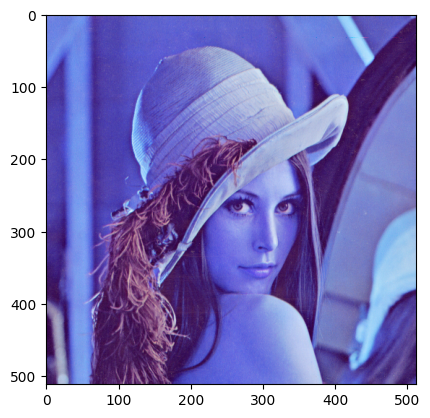

In [74]:
img = cv2.imread("test_image.png")
plt.imshow(img)

In [75]:
noise = np.random.normal(0.05, img.shape).astype(np.uint8)
noisy_image = cv2.add(img ,noise)

error: ignored

In [66]:
kernel = np.array(([3,0,3],[1,0,1],[3,0,3]))
img_smoothed = cv2.applyFilter(img, kernel)

AttributeError: ignored

In [76]:
img_smoothed = cv2.GaussianBlur(img, (5, 5), 0)

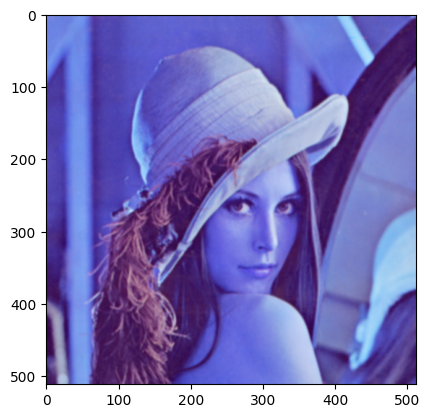

In [77]:
# Display the smoothed image
plt.imshow(img_smoothed)

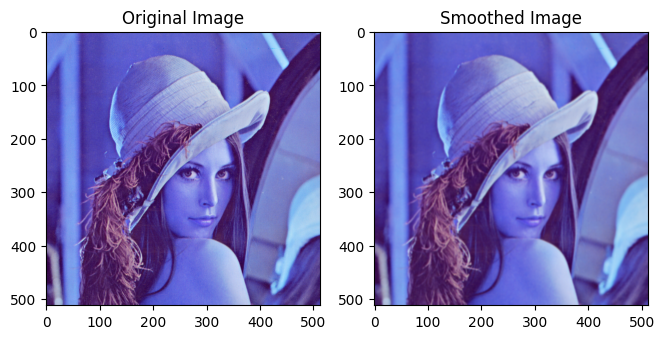

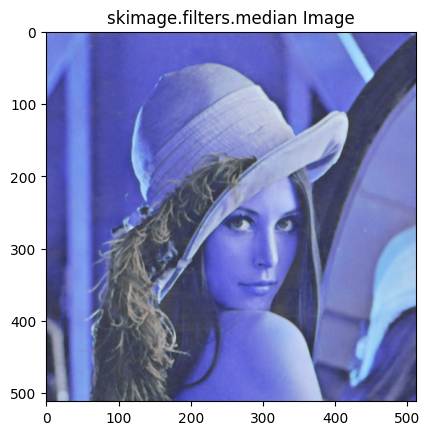

In [84]:
# Display original and smoothed images
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.subplot(132)
plt.imshow(img_smoothed, cmap='gray')
plt.title("Smoothed Image")
plt.show()
import skimage
cmp_img = skimage.filters.median(img)
plt.imshow(cmp_img, cmap='gray')
plt.title("skimage.filters.median Image")
plt.show()